In [ ]:
from sklearn.model_selection import train_test_split
import os
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Importar bibliotecas para aprendizado de máquina
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


# Importar funções de avaliação
from sklearn.metrics import accuracy_score, classification_report

# Importar pandas para manipulação de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
if 'titanic.csv' not in os.listdir():
    # Fazer upload apenas uma vez
    uploaded = files.upload()
else:
    print("Arquivo já carregado.")



Saving titanic.csv to titanic.csv


In [ ]:
# IMPORTANDO O DATASET PARA O DATAFRAME
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Dimensões do dataset:", df.shape)

Dimensões do dataset: (891, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


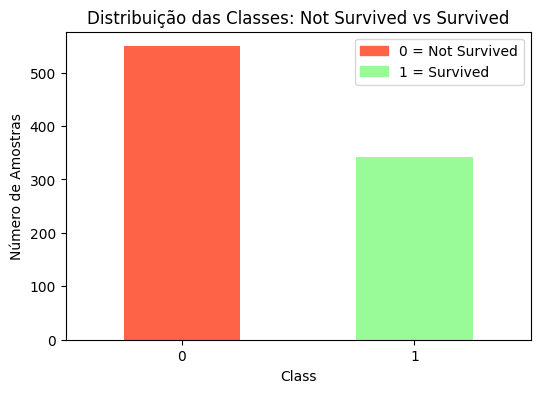

In [ ]:
# Plotando a distribuição das classes
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["Survived"].value_counts().plot(
    kind="bar", color=["#FF6347", "#98FB98"]
)
plt.title("Distribuição das Classes: Not Survived vs Survived")
plt.xlabel("Class")
plt.ylabel("Número de Amostras")
plt.xticks(rotation=0)
legenda_0 = mpatches.Patch(color="#FF6347", label="0 = Not Survived")
legenda_1 = mpatches.Patch(color="#98FB98", label="1 = Survived")
plt.legend(handles=[legenda_0, legenda_1])
# -------------------------------------------------

plt.show()

### Engenharia de Atributos

In [ ]:
import re

# Função para extrair o título do nome
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

# Criar a feature 'Title'
df['Title'] = df['Name'].apply(get_title)

# Mapear títulos raros para uma categoria 'Rare'
df['Title'] = df['Title'].replace([
    'Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Mlle', 'Ms', 'Mme'
], 'Rare')

# Mapear 'Mlle' e 'Ms' para 'Miss', e 'Mme' para 'Mrs'
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Exibir a contagem de títulos
print(df['Title'].value_counts())


Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [ ]:
import numpy as np
#Tratamento de valores nulos na feature Age por meio de imputação pela mediana

df['Age'] = df.groupby(['Pclass', 'Sex', 'Title'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df[['Pclass', 'Sex', 'Title','Age']]

,Pclass,Sex,Title,Age
0,3,male,Mr,22.0
1,1,female,Mrs,38.0
2,3,female,Miss,26.0
3,1,female,Mrs,35.0
4,3,male,Mr,35.0
...,...,...,...,...
886,2,male,Rare,27.0
887,1,female,Miss,19.0
888,3,female,Miss,18.0
889,1,male,Mr,26.0


In [ ]:
import pandas as pd
#Engenharia de atributos da variável Cabin: criação de CabinDeck e CabinKnown
#Para tratar valores nulos
df_cabin = pd.DataFrame({
    'CabinDeck': df['Cabin'].str[0].fillna('Unknown'),
    'CabinKnown': df['Cabin'].notna().astype(int)
})

df = pd.concat([df, df_cabin], axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,CabinDeck,CabinKnown
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Unknown,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Unknown,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,C,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Unknown,0


In [ ]:
# Engenharia de atributos: criação de novas variáveis

# Tamanho da família
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Identifica se o passageiro estava viajando sozinho
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Visualizar as novas variáveis
df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [ ]:
# Separação das variáveis independentes e do alvo

X = df.drop(
    ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'],
    axis=1
)

y = df['Survived']

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)

Dimensões de X: (891, 12)
Dimensões de y: (891,)


In [ ]:
# Divisão dos dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=3,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 12)
X_test: (179, 12)
y_train: (712,)
y_test: (179,)


## PASSO 4 — Pipeline de Dados e Engenharia de Atributos

### 4.1 — Engenharia de Atributos

As variáveis derivadas `CabinDeck`, `CabinKnown`, `FamilySize` e `IsAlone` foram criadas nas células anteriores. Elas enriquecem o dataset original sem utilizar a variável alvo `Survived`.

### 4.2 — Pré-processamento para aplicação do CFIS


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Variáveis numéricas
numeric_features = [
    'Age',
    'Fare',
    'FamilySize',
]

# Variáveis categóricas
categorical_features = [
    'Embarked',
    'CabinDeck',
    'Sex',
    'Title'
]

# Tratamento das variáveis numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Tratamento das variáveis categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Aplicar somente no conjunto de treinamento
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Recuperar nomes das features
feature_names = preprocessor.get_feature_names_out()

# Criar dataframe para o CFIS
df_cfis = pd.DataFrame(
    X_train_preprocessed,
    columns=feature_names,
    index=X_train.index
)

df_cfis['Survived'] = y_train

print('Dimensão após pré-processamento:', df_cfis.shape)
df_cfis.head()

Dimensão após pré-processamento: (712, 22)


,num__Age,num__Fare,num__FamilySize,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__CabinDeck_A,cat__CabinDeck_B,cat__CabinDeck_C,cat__CabinDeck_D,...,cat__CabinDeck_G,cat__CabinDeck_Unknown,cat__Sex_female,cat__Sex_male,cat__Title_Master,cat__Title_Miss,cat__Title_Mr,cat__Title_Mrs,cat__Title_Rare,Survived
258,0.427653,9.882764,-0.555374,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
615,-0.391851,0.674652,1.309844,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
708,-0.540852,2.456253,-0.555374,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
169,-0.093850,0.499596,-0.555374,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
17,0.129652,-0.395749,-0.555374,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1


### 4.3 — Seleção de Atributos com CFIS


In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression

def combined_feature_selection(df_cfis):
    # Dividir os dados em features (X) e target (y)
    X = df_cfis.drop(['Survived'], axis=1)  # Features
    y = df_cfis['Survived']  # Variável alvo

    # Inicializar o modelo de regressão logística
    logreg = LogisticRegression()
    logreg.fit(X, y)

    # Calcular a importância das features usando Permutation Importance
    result = permutation_importance(logreg, X, y, n_repeats=10, random_state=42)

    # Coletar as importâncias das features
    importances_permutation = result.importances_mean

    # Normalizar as importâncias das features para que a soma seja igual a 1
    normalized_importances_permutation = importances_permutation / np.sum(importances_permutation)

    # Coletar os coeficientes do modelo após o ajuste
    coefficients = logreg.coef_[0]

    # Normalizar os coeficientes
    normalized_coefficients = coefficients / np.linalg.norm(coefficients)

    # Calcular a correlação entre as features e a variável alvo
    correlation_scores = X.apply(lambda feature: feature.corr(y))

    # Calcular o CFIS como a média das métricas de importância, coeficientes e correlações
    combined_score = (normalized_importances_permutation + normalized_coefficients + correlation_scores) / 3

    # Normalizar as pontuações CFIS para que a soma seja igual a 100
    cfis_percentage = (combined_score / np.sum(combined_score)) * 100

    # Criar um DataFrame com as features e suas pontuações de Permutation Importance, coeficientes, correlações,
    # pontuações combinadas e porcentagens de importância CFIS
    feature_scores = pd.DataFrame({
        'Permutation Importance': normalized_importances_permutation,
        'Coefficient': coefficients,
        'Correlation': correlation_scores,
        'CFIS': combined_score,
        'CFIS (%)': cfis_percentage
    }, index=X.columns)

    # Ordenar os resultados de acordo com o CFIS em ordem decrescente
    sorted_features = feature_scores.sort_values(by='CFIS', ascending=False)

    # Formatar a coluna CFIS para destacar com uma cor diferente
    def highlight_cfis(value):
        if value > 0:
            return 'background-color: lightgreen'
        elif value < 0:
            return 'background-color: salmon'
        else:
            return ''

    # Aplicar a formatação de cores à coluna CFIS e ajustar a formatação da porcentagem
    sorted_features_styled = sorted_features.style.applymap(highlight_cfis, subset=['CFIS']).format({'CFIS (%)': '{:.2f}%'}).set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'left')]
    }])

    return sorted_features_styled

# Chamar a função com o dataframe df
sorted_features = combined_feature_selection(df_cfis)

# Exibir as features classificadas de acordo com a métrica CFIS
print("Features classificadas de acordo com a métrica CFIS(Combined Feature Importance Score):")
sorted_features


Features classificadas de acordo com a métrica CFIS(Combined Feature Importance Score):


,Permutation Importance,Coefficient,Correlation,CFIS,CFIS (%)
cat__Sex_female,0.093525,0.820599,0.520439,0.293046,56.33%
cat__Title_Master,0.094833,1.572479,0.107779,0.236917,45.54%
cat__Title_Mrs,0.003924,0.441007,0.307642,0.151359,29.10%
num__Fare,0.018967,0.326644,0.249474,0.124665,23.96%
cat__CabinDeck_D,-0.016351,0.720015,0.140812,0.119044,22.88%
cat__Embarked_C,-0.002616,0.358588,0.184666,0.099309,19.09%
cat__CabinDeck_E,0.009810,0.473028,0.109582,0.090750,17.45%
cat__CabinDeck_B,0.000654,0.227456,0.173982,0.082713,15.90%
cat__Title_Miss,0.001308,-0.335575,0.325682,0.072850,14.00%
cat__CabinDeck_G,0.000000,0.234850,0.067303,0.047731,9.18%


### 4.4 — Aplicação do CFIS ao conjunto de treinamento

In [ ]:
from pandas.api.types import is_string_dtype
# Aplicar o CFIS somente ao conjunto de treinamento
sorted_features = combined_feature_selection(df_cfis)

# Recuperar a tabela sem o estilo para obter os nomes das features
cfis_table = sorted_features.data.copy()

# Selecionar as 18 features mais relevantes (top 9 e bottom 9 para correlação positiva e negativa)
k = min(9, len(cfis_table) // 2) # Select top and bottom 'k' features, ensuring k is not too large
selected_features_head = cfis_table.head(k).index.tolist()
selected_features_tail = cfis_table.tail(k).index.tolist()
selected_features = list(set(selected_features_head + selected_features_tail))

discarded_features = [
    feature for feature in feature_names
    if feature not in selected_features
]

print('Features selecionadas pelo CFIS:')
for feature in selected_features:
    print('-', feature)
print('Quantidade de features selecionadas:', len(selected_features))

Features selecionadas pelo CFIS:
- num__Age
- cat__Title_Miss
- cat__Title_Master
- cat__Title_Rare
- cat__CabinDeck_Unknown
- cat__Embarked_Q
- cat__Embarked_S
- cat__CabinDeck_B
- cat__Embarked_C
- cat__Title_Mr
- cat__Sex_male
- cat__CabinDeck_D
- num__FamilySize
- cat__Title_Mrs
- cat__CabinDeck_E
- cat__Sex_female
- cat__CabinDeck_F
- num__Fare
Quantidade de features selecionadas: 18


In [ ]:
print('Features descartadas pelo CFIS:')
for feature in discarded_features:
    print('-', feature)

Features descartadas pelo CFIS:
- cat__CabinDeck_A
- cat__CabinDeck_C
- cat__CabinDeck_G


### 4.5 — Pipeline automatizado


In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Define um transformador customizado para a seleção de features CFIS
class CFISFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selected_indices):
        self.selected_indices = selected_indices

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[:, self.selected_indices]

    def __repr__(self):
        return "CFISFeatureSelector()" # Representação customizada

# Índices das features escolhidas pelo CFIS na saída do pré-processador
selected_indices = [
    list(feature_names).index(feature)
    for feature in selected_features
]

# Filtro baseado nas features selecionadas pelo CFIS usando o custom transformer
cfis_filter = CFISFeatureSelector(selected_indices)

# Pipeline de atributos: pré-processamento + filtro CFIS
feature_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('cfis_selection', cfis_filter)
])

# Ajuste somente com o treinamento
feature_pipeline.fit(X_train, y_train)

X_train_selected = feature_pipeline.transform(X_train)
X_test_selected = feature_pipeline.transform(X_test)

print('Dimensão original de X_train:', X_train.shape)
print('Dimensão após pré-processamento:', len(feature_names))
print('Dimensão após seleção CFIS:', X_train_selected.shape)
print('Dimensão de X_test após seleção CFIS:', X_test_selected.shape)

Dimensão original de X_train: (712, 12)
Dimensão após pré-processamento: 21
Dimensão após seleção CFIS: (712, 18)
Dimensão de X_test após seleção CFIS: (179, 18)


In [ ]:
feature_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Embarked', 'CabinDeck',
                                                   'Sex', 'Title'])])),
                ('cfis_selection',
                 CFISFeatureSelector(selected_indices=[0, 17, 16, 20, 13, 4, 5, 7, 3, 18, 15, 9, 2, 19, 10, 14, 11, 1]))])

### 4.6 — Pipelines dos modelos

In [ ]:
from xgboost import XGBClassifier
from sklearn.svm import NuSVC, LinearSVC
# Instanciar modelos de classificação
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=600),
    'Support Vector Machine': SVC(),
    'NuSupport Vector Machine': NuSVC(),
    'Linear Support Vector Machine': LinearSVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
}

# Armazenar resultados
results = []

# Treinar e avaliar cada modelo utilizando o pipeline de atributos
for name, model in models.items():
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('cfis_selection', cfis_filter),
        ('model', model)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)

    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    report_train = classification_report(
        y_train, y_pred_train, output_dict=True
    )
    report_test = classification_report(
        y_test, y_pred_test, output_dict=True
    )

    results.append({
        'Modelo': name,
        'Acurácia Treino': accuracy_train,
        'Acurácia Teste': accuracy_test,
        **report_train['weighted avg'],
        **report_test['weighted avg']
    })

# Criar DataFrame com os resultados
df_results = pd.DataFrame(results)

# Ordenar pela acurácia de teste
df_results_sorted = df_results.sort_values(
    by='Acurácia Teste', ascending=False
)
# Definir uma função para aplicar formatação condicional e alinhamento à esquerda às células
def style_format(val):
    if val == df_results_sorted.iloc[0]['Modelo']:
        color = 'green'
    elif val == df_results_sorted.iloc[1]['Modelo']:
        color = 'yellow'
    elif val == df_results_sorted.iloc[2]['Modelo']:
        color = 'red'
    else:
        color = 'black'
    return f'color: {color}; text-align: left;'

# Aplicar formatação condicional e alinhamento à esquerda à coluna 'Modelo'
styled_df = df_results_sorted.style.applymap(style_format, subset=['Modelo'])

# Exibir DataFrame formatado
styled_df


,Modelo,Acurácia Treino,Acurácia Teste,precision,recall,f1-score,support
2,Support Vector Machine,0.832865,0.860335,0.859618,0.860335,0.859723,179.000000
4,Linear Support Vector Machine,0.821629,0.860335,0.860004,0.860335,0.860141,179.000000
3,NuSupport Vector Machine,0.827247,0.854749,0.854144,0.854749,0.854335,179.000000
1,Logistic Regression,0.825843,0.854749,0.854144,0.854749,0.854335,179.000000
0,Random Forest,0.988764,0.849162,0.854113,0.849162,0.850324,179.000000
5,K-Nearest Neighbors,0.848315,0.837989,0.836881,0.837989,0.836744,179.000000
7,XGBoost,0.818820,0.826816,0.825782,0.826816,0.826056,179.000000
6,Decision Tree,0.988764,0.810056,0.814482,0.810056,0.811350,179.000000


In [ ]:
from sklearn.svm import SVC

# 1. Integrar o algoritmo de classificação (SVM) no Pipeline final
# O 'feature_pipeline' já inclui o pré-processamento e a seleção de features
final_svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('cfis_selection', cfis_filter),
    ('classifier', SVC(random_state=42)) # Adicionando o classificador SVM
])

# 2. Realizar o treinamento do pipeline completo utilizando os dados de treino
print("Treinando o pipeline final com SVM...")
final_svm_pipeline.fit(X_train, y_train)
print("Treinamento concluído!")

# 3. Exibir o pipeline treinado e a confirmação da execução do modelo
print("\nPipeline SVM treinado:")
final_svm_pipeline

Treinando o pipeline final com SVM...
Treinamento concluído!

Pipeline SVM treinado:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Embarked', 'CabinDeck',
                                                   'Sex', 'Title'])])),
                ('cfis_selection',
                 CFISFeatureSelector(selected_indices=[0, 17, 16, 20, 13, 4, 5, 7, 3, 18, 15, 9, 2, 19, 10, 14, 11, 1])),
                ('classifier', SVC(random_state=42))])

##6.1: Avaliação por Métricas de Desempenho e Relatório de Classificação

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Fazer previsões no conjunto de teste
y_pred = final_svm_pipeline.predict(X_test)

# Gerar o relatório de classificação
print("Relatório de Classificação no conjunto de Teste:")
print(classification_report(y_test, y_pred))

# Calcular e apresentar o valor da métrica ROC-AUC
# Para SVC, usamos decision_function para obter os scores necessários para ROC-AUC
y_score = final_svm_pipeline.decision_function(X_test)
roc_auc = roc_auc_score(y_test, y_score)
print(f"\nROC-AUC Score no conjunto de Teste: {roc_auc:.4f}")

Relatório de Classificação no conjunto de Teste:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       110
           1       0.83      0.80      0.81        69

    accuracy                           0.86       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.86      0.86      0.86       179


ROC-AUC Score no conjunto de Teste: 0.8899


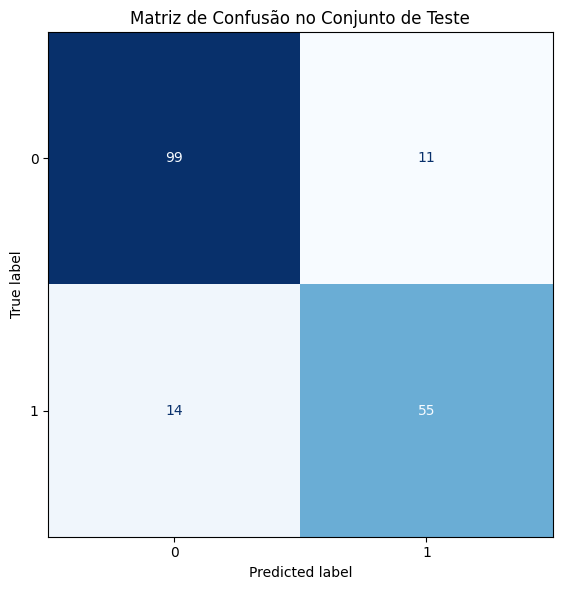

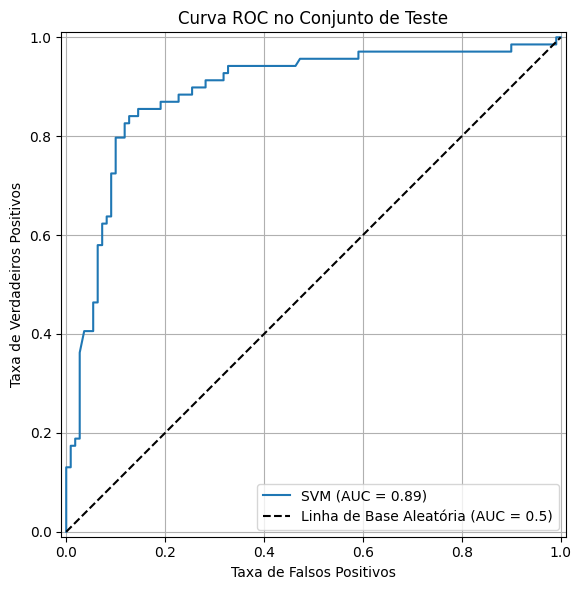

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Plotar a Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap=plt.cm.Blues,
    colorbar=False,
    ax=ax
)
ax.set_title('Matriz de Confusão no Conjunto de Teste')
plt.tight_layout()
plt.show()

# 2. Plotar a Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_score,
    name='SVM',
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Linha de Base Aleatória (AUC = 0.5)')
ax.set_title('Curva ROC no Conjunto de Teste')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# 1. Aplicar a predição do modelo nos dados de treino (X_train)
y_pred_train = final_svm_pipeline.predict(X_train)

# 2. Calcular e exibir as métricas para ambos os conjuntos lado a lado
accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

accuracy_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)

print("Comparação de Desempenho (Treino vs. Teste):\n")
print(f"Acurácia no Treino: {accuracy_train:.4f}")
print(f"Acurácia no Teste: {accuracy_test:.4f}\n")
print(f"F1-Score no Treino: {f1_train:.4f}")
print(f"F1-Score no Teste: {f1_test:.4f}\n")

# 3. Identificar o gap de desempenho
accuracy_gap = abs(accuracy_train - accuracy_test)
f1_gap = abs(f1_train - f1_test)

print(f"Gap de Acurácia (Treino - Teste): {accuracy_gap:.4f}")
print(f"Gap de F1-Score (Treino - Teste): {f1_gap:.4f}\n")

if accuracy_gap > 0.1 or f1_gap > 0.1: # Exemplo de limiar para gap
    if accuracy_train > accuracy_test and f1_train > f1_test:
        print("Observado um possível Overfitting: o modelo performa significativamente melhor no treino do que no teste.")
    else:
        print("Observado um possível Underfitting ou baixa performance geral.")
else:
    print("O modelo apresenta um bom balanço entre o desempenho no treino e no teste, indicando generalização adequada.")

Comparação de Desempenho (Treino vs. Teste):

Acurácia no Treino: 0.8329
Acurácia no Teste: 0.8603

F1-Score no Treino: 0.7698
F1-Score no Teste: 0.8148

Gap de Acurácia (Treino - Teste): 0.0275
Gap de F1-Score (Treino - Teste): 0.0450

O modelo apresenta um bom balanço entre o desempenho no treino e no teste, indicando generalização adequada.
